# OULAD Graph Pipeline — Canonical Analysis Notebook

**Purpose**: Reproducible record of the Week 8 leakage-safe enrollment-centric graph.

This notebook:
1. Runs the full graph pipeline via `src/graph_pipeline.py`
2. Displays the integrity validation summary
3. Demonstrates `random_student_split` and `lcpo_split` on the enrollment supervision table

> **Note**: GNN training (GraphSAGE) and comparative evaluation are left for the following week.

**Target definition** (fixed throughout this project):
- `1 = at-risk` → Fail or Withdrawn (positive class)
- `0 = success` → Pass or Distinction
- All Precision, Recall, F1, AUPRC values refer to the at-risk class.


## 0. Setup


In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebooks/ directory
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from graph_pipeline import run_pipeline
from oulad_data import random_student_split, lcpo_split
from config import GRAPH_ARTIFACTS_DIR, GRAPH_VALIDATION_DIR

print('Project root:', PROJECT_ROOT)
print('Artifacts dir:', GRAPH_ARTIFACTS_DIR)


Project root: /Users/olivialoza/Documents/Development/OULAD
Artifacts dir: /Users/olivialoza/Documents/Development/OULAD/results/graph/artifacts


## 1. Run the Week 8 Graph Pipeline

Runs all 7 stages: load → filter (cutoff 56 days) → nodes → edges → enrollments → validate → persist.
Assessment filtering uses **dual guard (Strategy B)**: `due_date ≤ window` AND `date_submitted ≤ window`.


In [2]:
result = run_pipeline(
    week=8,
    data_dir=str(PROJECT_ROOT / 'data' / 'raw'),
    save_dir=str(GRAPH_ARTIFACTS_DIR),
)


  [impute] student: 971 null(s) before imputation — imd_band=971
  [impute] vle_resource: 10486 null(s) before imputation — week_from=5243, week_to=5243


Graph integrity check results:
  dup_nodes_student: 0
  dup_nodes_course_presentation: 0
  dup_nodes_assessment: 0
  dup_nodes_vle_resource: 0
  dup_edges_enrolled_in: 0
  dup_edges_contains_assess: 0
  dup_edges_has_resource: 0
  dup_edges_submitted: 0
  dup_edges_interacted_with: 0
  dangling_enrolled_in_src: 0
  dangling_enrolled_in_dst: 0
  dup_enrollments: 0
  null_values_student: 0
  null_values_course_presentation: 0
  null_values_assessment: 0
  null_values_vle_resource: 0
  label_at_risk: 17208
  label_success: 15385
  label_at_risk_rate: 0.528


Saved 10 artifacts to /Users/olivialoza/Documents/Development/OULAD/results/graph/artifacts/
  nodes_student: week08_nodes_student.parquet
  nodes_course_presentation: week08_nodes_course_presentation.parquet
  nodes_assessment: week08_nodes_assessment.parquet
  nodes_vle_resource: week08_nodes_vle_resource.parquet
  edges_enrolled_in: week08_edges_enrolled_in.parquet
  edges_contains_assess: week08_edges_contains_assess.parquet
  edges_has_resource: week08_edges_has_resource.parquet
  edges_submitted: week08_edges_submitted.parquet
  edges_interacted_with: week08_edges_interacted_with.parquet
  enrollments: week08_enrollments.parquet

Pipeline complete — 4.8s, peak memory 1362.6 MB


## 2. Graph Statistics


In [3]:
nodes = result['nodes']
edges = result['edges']
enrollments = result['enrollments']

print('=== NODE COUNTS ===')
for ntype, ndf in nodes.items():
    print(f'  {ntype}: {len(ndf):,}')

print('\n=== EDGE COUNTS ===')
for etype, edf in edges.items():
    print(f'  {etype}: {len(edf):,}')

print(f'\n=== ENROLLMENTS ===')
print(f'  Total:   {len(enrollments):,}')
at_risk = int((enrollments["target"] == 1).sum())
print(f'  At-risk: {at_risk:,} ({at_risk/len(enrollments)*100:.1f}%)')
print(f'  Success: {len(enrollments)-at_risk:,} ({(len(enrollments)-at_risk)/len(enrollments)*100:.1f}%)')

print(f'\n=== PERFORMANCE ===')
print(f'  Elapsed:     {result["elapsed_seconds"]:.1f}s')
print(f'  Peak memory: {result["peak_memory_mb"]} MB')


=== NODE COUNTS ===
  student: 28,785
  course_presentation: 22
  assessment: 40
  vle_resource: 6,364

=== EDGE COUNTS ===
  enrolled_in: 32,593
  contains_assess: 40
  has_resource: 6,364
  submitted: 44,927
  interacted_with: 1,056,217

=== ENROLLMENTS ===
  Total:   32,593
  At-risk: 17,208 (52.8%)
  Success: 15,385 (47.2%)

=== PERFORMANCE ===
  Elapsed:     4.8s
  Peak memory: 1362.6 MB


## 3. Validation Summary

Read and display the integrity validation report generated by the pipeline.


In [4]:
validation_summary = GRAPH_VALIDATION_DIR / 'week08_validation_summary.txt'
if validation_summary.exists():
    print(validation_summary.read_text())
else:
    print('Integrity checks from pipeline run:')
    for k, v in result['integrity'].items():
        flag = ' \u26a0' if isinstance(v, int) and k.startswith(('dup_', 'dangling_', 'null_')) and v > 0 else ''
        print(f'  {k}: {v}{flag}')


  OULAD Graph Validation Summary — Week 8

Construction runtime : 5.6 s  |  Peak memory : 1049.0 MB

── Node counts ──────────────────────────────────────────────────
  student                       28,785
  course_presentation               22
  assessment                        40
  vle_resource                   6,364

── Edge counts ──────────────────────────────────────────────────
  enrolled_in                   32,593
  contains_assess                   40
  has_resource                   6,364
  submitted                     44,927
  interacted_with            1,056,217
  enrollments                   32,593

── Duplicates ───────────────────────────────────────────────────
  Duplicate nodes (all types) : 0
  Duplicate edges (all types) : 0
  Duplicate enrollments       : 0

── Dangling edges ───────────────────────────────────────────────
  enrolled_in               src=0  dst=0
  contains_assess           src=0  dst=0
  has_resource              src=0  dst=0
  submitted      

> **Re-run note**: The output above was cleared because the validation summary format
> was updated (pre-imputation null counts and `submitted_max_date_submitted` check added).
> To refresh all cell outputs, first build all four prediction-week graphs:
> ```bash
> python src/run_graph_pipeline.py --week 2
> python src/run_graph_pipeline.py --week 4
> python src/run_graph_pipeline.py --week 6
> python src/run_graph_pipeline.py --week 8
> python src/save_graph_splits.py
> python src/summarize_graph_weeks.py
> ```
> Then re-execute this notebook top-to-bottom.


## 4. Label Distribution by Course-Presentation


In [5]:
label_dist = (
    enrollments.groupby(['code_module', 'code_presentation'])['target']
    .agg(total='count', at_risk='sum')
    .assign(at_risk_rate=lambda d: (d['at_risk'] / d['total']).round(3))
    .sort_values('at_risk_rate', ascending=False)
    .reset_index()
)
print(label_dist.to_string(index=False))


code_module code_presentation  total  at_risk  at_risk_rate
        CCC             2014B   1936     1273         0.658
        DDD             2014B   1228      749         0.610
        DDD             2013B   1303      793         0.609
        CCC             2014J   2498     1483         0.594
        DDD             2013J   1938     1109         0.572
        FFF             2014B   1500      846         0.564
        DDD             2014J   1803     1011         0.561
        BBB             2014B   1613      886         0.549
        BBB             2013B   1767      964         0.546
        FFF             2014J   2365     1248         0.528
        BBB             2013J   2237     1165         0.521
        FFF             2013J   2283     1188         0.520
        FFF             2013B   1614      832         0.515
        BBB             2014J   2292     1140         0.497
        EEE             2014B    694      337         0.486
        GGG             2014B    833    

In [6]:
# Shared plot style for all visualizations
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
ACCENT  = '#3b82d4'
ATRISK  = '#e05252'   # at-risk
SUCCESS = '#52a852'   # success
print('Plot style configured.')


Plot style configured.


## 5. random_student_split Demo

Demonstrates `random_student_split` from `src/oulad_data.py` on the Week 8 enrollment supervision table.

- Splits are on **unique students** — the same student cannot appear in more than one partition.
- Default fractions: val=10%, test=20%, train=70% of unique students.


In [7]:
train_mask, val_mask, test_mask = random_student_split(
    enrollments, val_frac=0.1, test_frac=0.2, seed=42
)

train_enroll = enrollments[train_mask]
val_enroll   = enrollments[val_mask]
test_enroll  = enrollments[test_mask]

print('=== RANDOM STUDENT SPLIT (enrollment rows) ===')
print(f'  Train: {len(train_enroll):,} rows | {train_enroll["id_student"].nunique():,} unique students')
print(f'  Val:   {len(val_enroll):,} rows | {val_enroll["id_student"].nunique():,} unique students')
print(f'  Test:  {len(test_enroll):,} rows | {test_enroll["id_student"].nunique():,} unique students')

# Verify no student overlap between train and test
train_students = set(train_enroll['id_student'].unique())
test_students  = set(test_enroll['id_student'].unique())
assert train_students.isdisjoint(test_students), 'Student overlap detected!'
print('\n\u2713 No student overlap between train and test.')

# At-risk rates per split
for name, df in [('Train', train_enroll), ('Val', val_enroll), ('Test', test_enroll)]:
    rate = df['target'].mean()
    print(f'  At-risk rate \u2014 {name}: {rate:.3f}')


=== RANDOM STUDENT SPLIT (enrollment rows) ===
  Train: 22,801 rows | 20,150 unique students
  Val:   3,280 rows | 2,878 unique students
  Test:  6,512 rows | 5,757 unique students

✓ No student overlap between train and test.
  At-risk rate — Train: 0.529
  At-risk rate — Val: 0.524
  At-risk rate — Test: 0.526


## 6. LCPO Split Demo

Demonstrates `lcpo_split` from `src/oulad_data.py`.

- For each of the 22 course-presentations, all enrollments in that presentation are held out as test; the rest are train.
- Verifies that all 22 splits yield non-empty train and test sets.


In [8]:
presentations = (
    enrollments[['code_module', 'code_presentation']]
    .drop_duplicates()
    .sort_values(['code_module', 'code_presentation'])
    .reset_index(drop=True)
)

print(f'Course-presentations: {len(presentations)}')
print(f'{"-"*60}')
print(f'{"Module":<12} {"Presentation":<14} {"Train":>8} {"Test":>8} {"Test at-risk%":>14}')
print(f'{"-"*60}')

for _, row in presentations.iterrows():
    train_m, test_m = lcpo_split(enrollments, row.code_module, row.code_presentation)
    test_rate = enrollments.loc[test_m, 'target'].mean()
    print(
        f'{row.code_module:<12} {row.code_presentation:<14}'
        f' {train_m.sum():>8,} {test_m.sum():>8,} {test_rate*100:>13.1f}%'
    )

print(f'\n\u2713 All {len(presentations)} course-presentations yield non-empty train and test splits.')


Course-presentations: 22
------------------------------------------------------------
Module       Presentation      Train     Test  Test at-risk%
------------------------------------------------------------
AAA          2013J            32,210      383          27.4%
AAA          2014J            32,228      365          30.7%
BBB          2013B            30,826    1,767          54.6%
BBB          2013J            30,356    2,237          52.1%
BBB          2014B            30,980    1,613          54.9%
BBB          2014J            30,301    2,292          49.7%
CCC          2014B            30,657    1,936          65.8%
CCC          2014J            30,095    2,498          59.4%
DDD          2013B            31,290    1,303          60.9%
DDD          2013J            30,655    1,938          57.2%
DDD          2014B            31,365    1,228          61.0%
DDD          2014J            30,790    1,803          56.1%
EEE          2013J            31,541    1,052          42.1%

## 7. Node Feature Null Audit

Confirms that all node feature tables have zero nulls after the imputation applied in `build_node_tables()`.


In [9]:
print('Post-imputation null counts per node type:')
for ntype, ndf in nodes.items():
    feat_cols = [c for c in ndf.columns if c != 'node_idx']
    nulls = ndf[feat_cols].isnull().sum()
    total = int(nulls.sum())
    status = '\u2713' if total == 0 else f'\u26a0 {total} nulls'
    print(f'  {ntype}: {status}')
    if total > 0:
        print('   ', nulls[nulls > 0].to_dict())


Post-imputation null counts per node type:
  student: ✓
  course_presentation: ✓
  assessment: ✓
  vle_resource: ✓


## 8. Visualization — At-Risk Rate by Course-Presentation

Sorted bar chart of the at-risk rate (Fail/Withdrawn) per course-presentation.
Dashed line marks the overall 52.8% base rate.


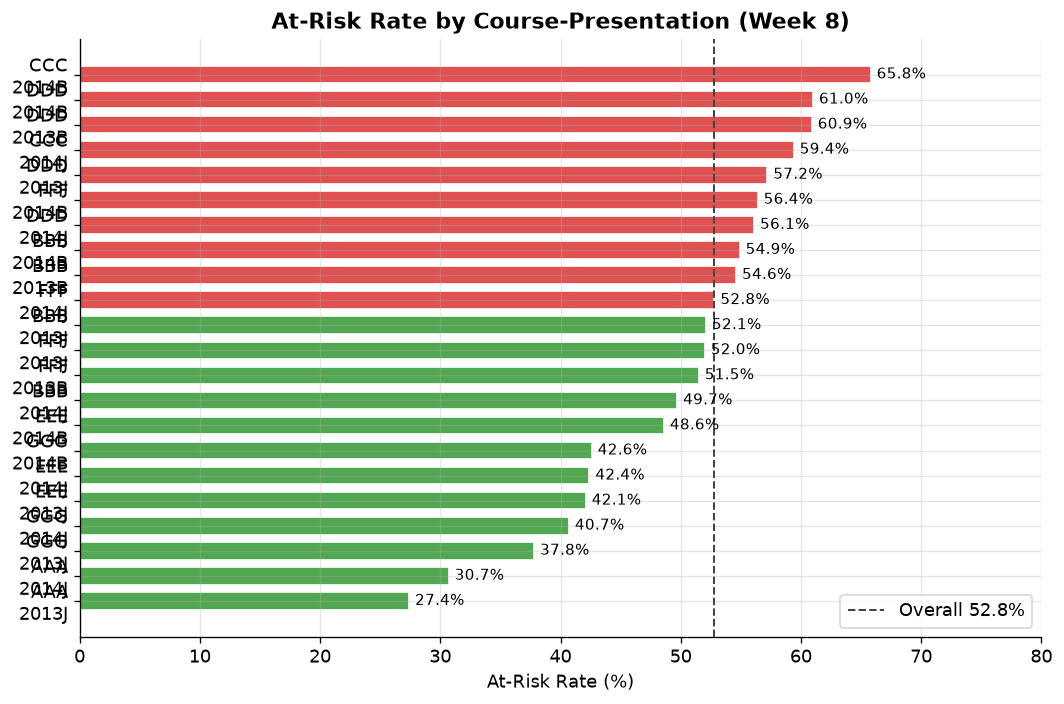

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

ld = label_dist.sort_values('at_risk_rate')
labels = ld['code_module'] + '\n' + ld['code_presentation']
colors = [ATRISK if r >= 0.528 else SUCCESS for r in ld['at_risk_rate']]

bars = ax.barh(labels, ld['at_risk_rate'] * 100, color=colors, edgecolor='white', height=0.7)
ax.axvline(52.8, color='#444', linewidth=1.2, linestyle='--', label='Overall 52.8%')

for bar, val in zip(bars, ld['at_risk_rate'] * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('At-Risk Rate (%)')
ax.set_title('At-Risk Rate by Course-Presentation (Week 8)', fontweight='bold')
ax.legend()
ax.set_xlim(0, 80)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_atrisk_by_course.png', bbox_inches='tight')
plt.show()


## 9. Visualization — Overall Class Balance


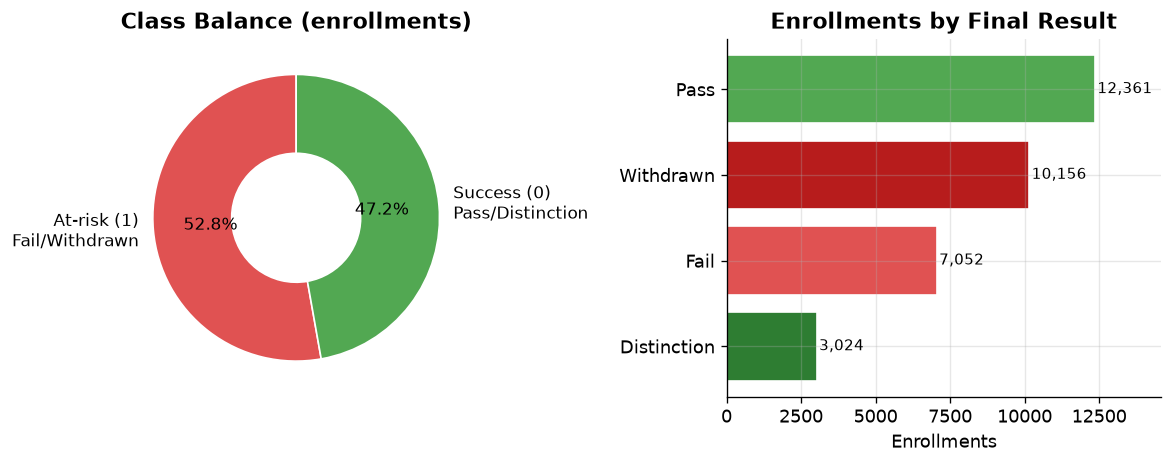

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Donut
at_risk_n  = int((enrollments['target'] == 1).sum())
success_n  = int((enrollments['target'] == 0).sum())
sizes = [at_risk_n, success_n]
clrs  = [ATRISK, SUCCESS]
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=['At-risk (1)\nFail/Withdrawn', 'Success (0)\nPass/Distinction'],
    colors=clrs, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white'),
    textprops={'fontsize': 10},
)
axes[0].set_title('Class Balance (enrollments)', fontweight='bold')

# Bar breakdown by final_result
result_counts = enrollments['final_result'].value_counts().sort_values()
result_colors = {'Pass': SUCCESS, 'Distinction': '#2e7d32',
                 'Fail': ATRISK, 'Withdrawn': '#b71c1c'}
bar_colors = [result_colors.get(r, ACCENT) for r in result_counts.index]
axes[1].barh(result_counts.index, result_counts.values, color=bar_colors, edgecolor='white')
for i, (idx, val) in enumerate(result_counts.items()):
    axes[1].text(val + 80, i, f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Enrollments')
axes[1].set_title('Enrollments by Final Result', fontweight='bold')
axes[1].set_xlim(0, result_counts.max() * 1.18)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_class_balance.png', bbox_inches='tight')
plt.show()


## 10. Visualization — random_student_split Quality

Stacked bar showing enrollment counts by at-risk / success across Train / Val / Test.
Confirms the splits are approximately stratified.


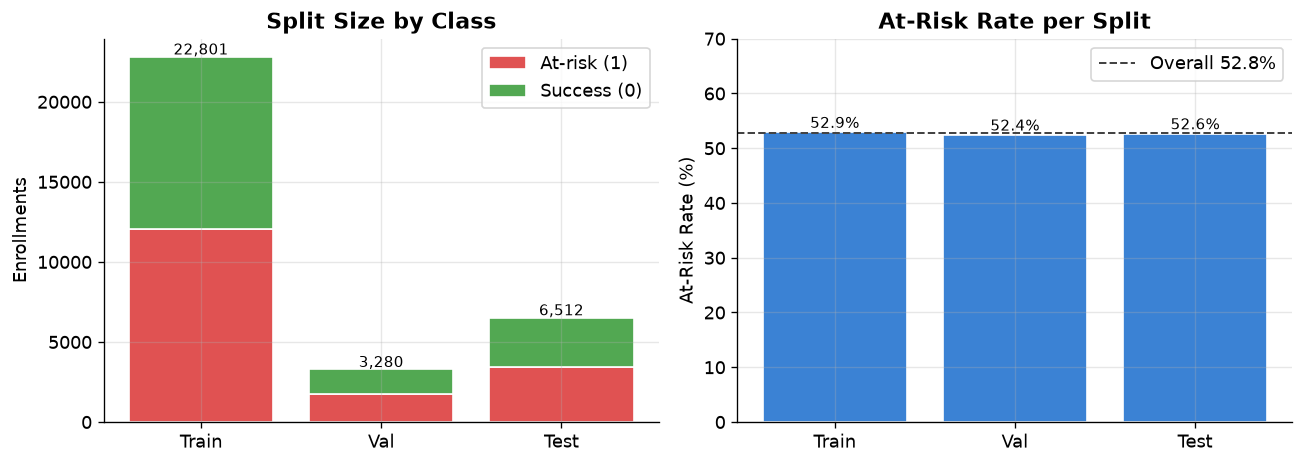

In [12]:
split_data = {
    'Train': train_enroll,
    'Val':   val_enroll,
    'Test':  test_enroll,
}

split_names = list(split_data.keys())
at_risk_counts  = [int((df['target'] == 1).sum()) for df in split_data.values()]
success_counts  = [int((df['target'] == 0).sum()) for df in split_data.values()]
totals          = [a + s for a, s in zip(at_risk_counts, success_counts)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stacked bar — absolute counts
x = np.arange(len(split_names))
b1 = axes[0].bar(x, at_risk_counts, color=ATRISK, label='At-risk (1)', edgecolor='white')
b2 = axes[0].bar(x, success_counts, bottom=at_risk_counts, color=SUCCESS,
                  label='Success (0)', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(split_names)
axes[0].set_ylabel('Enrollments')
axes[0].set_title('Split Size by Class', fontweight='bold')
axes[0].legend()
for xi, tot in zip(x, totals):
    axes[0].text(xi, tot + 150, f'{tot:,}', ha='center', fontsize=9)

# At-risk rate per split
rates = [a / t * 100 for a, t in zip(at_risk_counts, totals)]
axes[1].bar(x, rates, color=ACCENT, edgecolor='white')
axes[1].axhline(52.8, color='#444', linewidth=1.2, linestyle='--', label='Overall 52.8%')
axes[1].set_xticks(x); axes[1].set_xticklabels(split_names)
axes[1].set_ylabel('At-Risk Rate (%)')
axes[1].set_title('At-Risk Rate per Split', fontweight='bold')
axes[1].set_ylim(0, 70)
axes[1].legend()
for xi, r in zip(x, rates):
    axes[1].text(xi, r + 0.8, f'{r:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_split_quality.png', bbox_inches='tight')
plt.show()


## 11. Visualization — Enrollments per Student

Most students appear in exactly one course-presentation; some appear in 2–3.
Justifies student-level splitting: row-level splits would leak multi-course students.


   students
1     25247
2      3293
3       221
4        23
5         1


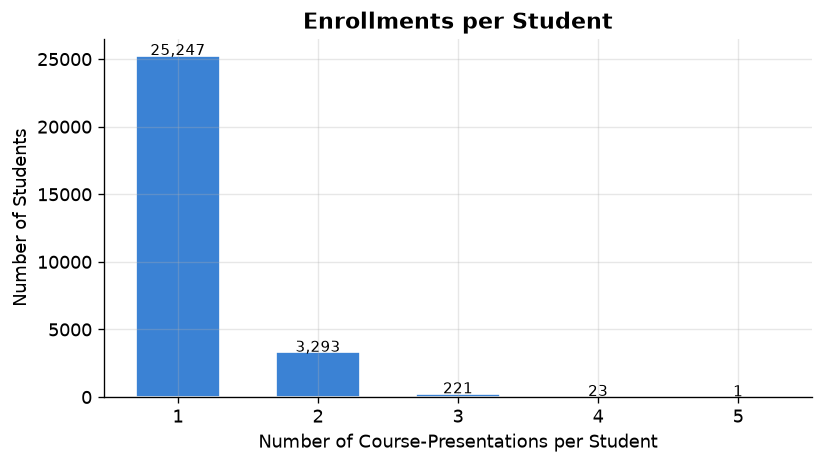

In [13]:
enroll_per_student = enrollments.groupby('id_student').size()

fig, ax = plt.subplots(figsize=(7, 4))
counts = enroll_per_student.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=ACCENT, edgecolor='white', width=0.6)
ax.set_xlabel('Number of Course-Presentations per Student')
ax.set_ylabel('Number of Students')
ax.set_title('Enrollments per Student', fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for xi, yi in zip(counts.index, counts.values):
    ax.text(xi, yi + 50, f'{yi:,}', ha='center', fontsize=9)

print(enroll_per_student.value_counts().sort_index().rename('students').to_frame())
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_enrollments_per_student.png', bbox_inches='tight')
plt.show()


## 12. Visualization — Graph Scale: Node and Edge Counts

Log-scale horizontal bar chart across all 4 node types and 5 edge types.


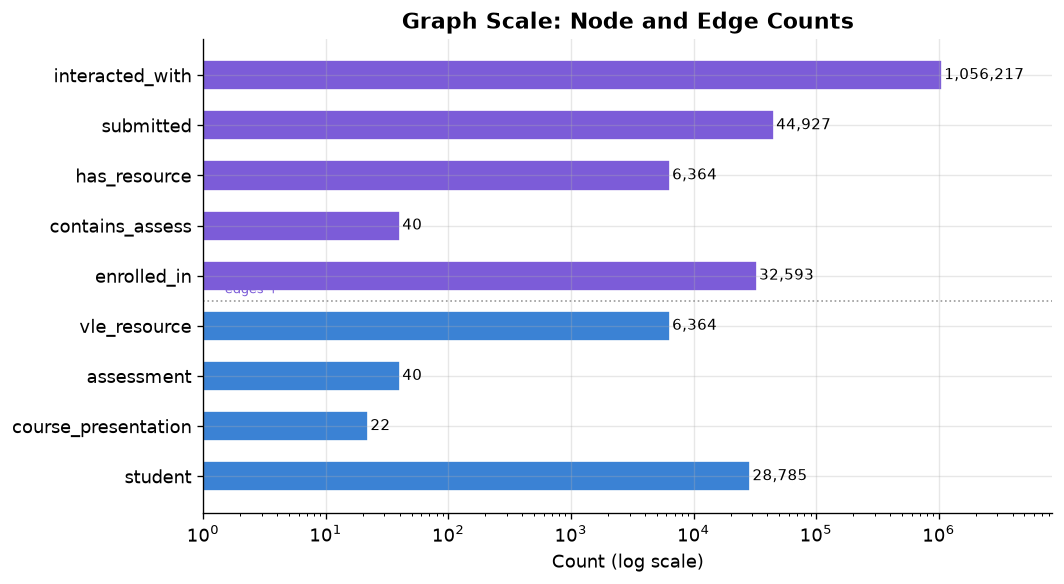

In [14]:
node_counts = {nt: len(df) for nt, df in nodes.items()}
edge_counts = {et: len(df) for et, df in edges.items()}

all_labels = list(node_counts.keys()) + list(edge_counts.keys())
all_values = list(node_counts.values()) + list(edge_counts.values())
all_colors = [ACCENT] * len(node_counts) + ['#7c5cd8'] * len(edge_counts)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(all_labels))
bars = ax.barh(y, all_values, color=all_colors, edgecolor='white', height=0.6)
ax.set_yticks(y)
ax.set_yticklabels(all_labels)
ax.set_xscale('log')
ax.set_xlabel('Count (log scale)')
ax.set_title('Graph Scale: Node and Edge Counts', fontweight='bold')

# Divider between nodes and edges
ax.axhline(len(node_counts) - 0.5, color='#999', linewidth=1, linestyle=':')
ax.text(1.5, len(node_counts) - 0.5 + 0.15, 'edges ↑', fontsize=8, color='#7c5cd8')
ax.text(1.5, len(node_counts) - 0.5 - 0.45, 'nodes ↓', fontsize=8, color=ACCENT)

for bar, val in zip(bars, all_values):
    ax.text(val * 1.05, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlim(1, max(all_values) * 8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_graph_scale.png', bbox_inches='tight')
plt.show()


## 13. Visualization — VLE Interaction Degree Distribution

Log-scale histogram of student out-degree in the `interacted_with` edge.
Reveals graph sparsity and informs GNN layer depth choices.


Degree  — min: 1, median: 33, mean: 40.7, max: 342
Clicks  — min: 1, median: 3, mean: 14.6, max: 7056


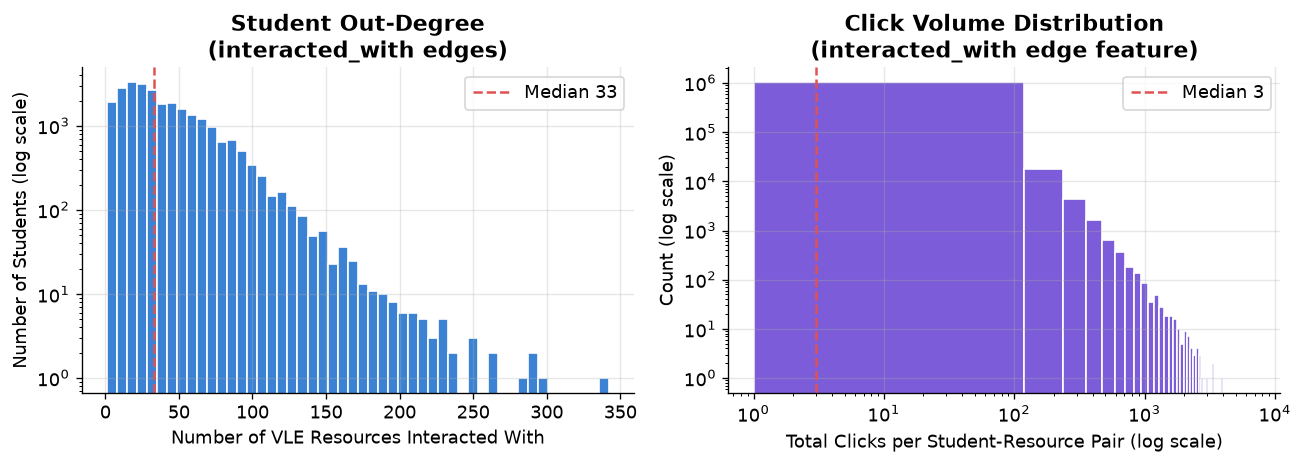

In [15]:
iw = edges['interacted_with']
degree = iw.groupby('src')['dst'].count()  # student out-degree

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Degree histogram
axes[0].hist(degree.values, bins=50, color=ACCENT, edgecolor='white', log=True)
axes[0].set_xlabel('Number of VLE Resources Interacted With')
axes[0].set_ylabel('Number of Students (log scale)')
axes[0].set_title('Student Out-Degree\n(interacted_with edges)', fontweight='bold')
axes[0].axvline(degree.median(), color=ATRISK, linewidth=1.5,
                linestyle='--', label=f'Median {degree.median():.0f}')
axes[0].legend()

# Total clicks histogram (log-log)
clicks = iw['total_clicks']
axes[1].hist(clicks.values, bins=60, color='#7c5cd8', edgecolor='white', log=True)
axes[1].set_xscale('log')
axes[1].set_xlabel('Total Clicks per Student-Resource Pair (log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Click Volume Distribution\n(interacted_with edge feature)', fontweight='bold')
axes[1].axvline(clicks.median(), color=ATRISK, linewidth=1.5,
                linestyle='--', label=f'Median {clicks.median():.0f}')
axes[1].legend()

print(f'Degree  — min: {degree.min()}, median: {degree.median():.0f}, '
      f'mean: {degree.mean():.1f}, max: {degree.max()}')
print(f'Clicks  — min: {clicks.min()}, median: {clicks.median():.0f}, '
      f'mean: {clicks.mean():.1f}, max: {clicks.max()}')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_degree_clicks.png', bbox_inches='tight')
plt.show()


## 14. Visualization — LCPO Split Sizes and At-Risk Rates

Two-panel chart across all 22 course-presentations.
Left: test set size. Right: at-risk rate in each test fold.
Highlights which LCPO folds are small or have atypical class balance.


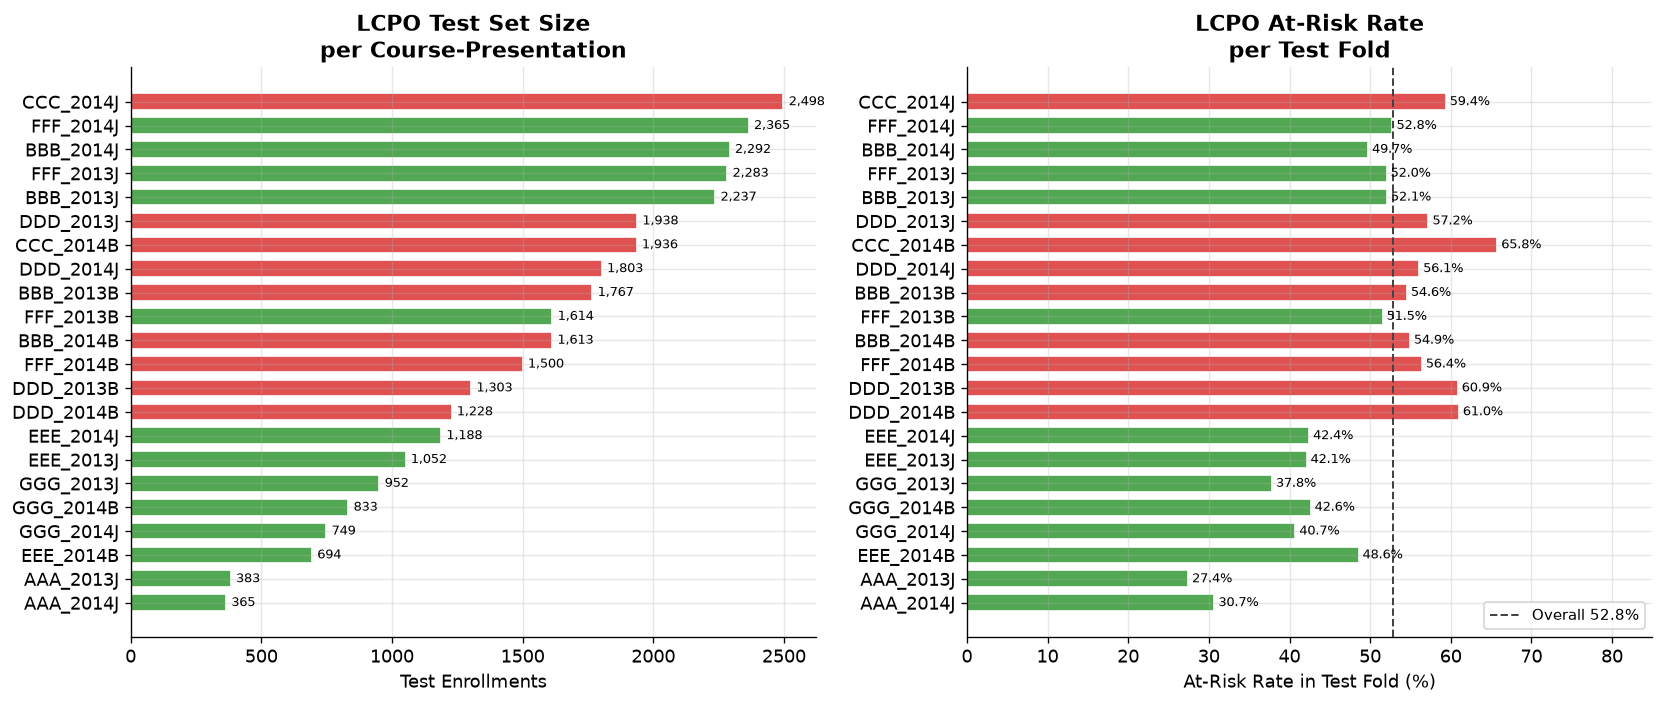

In [16]:
pres_labels = (
    presentations['code_module'] + '_' + presentations['code_presentation']
).tolist()
test_sizes, test_rates, train_sizes = [], [], []
for _, row in presentations.iterrows():
    tr, te = lcpo_split(enrollments, row.code_module, row.code_presentation)
    test_sizes.append(te.sum())
    test_rates.append(enrollments.loc[te, 'target'].mean() * 100)
    train_sizes.append(tr.sum())

order = np.argsort(test_sizes)
sorted_labels = [pres_labels[i] for i in order]
sorted_sizes  = [test_sizes[i]  for i in order]
sorted_rates  = [test_rates[i]  for i in order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set sizes
bar_colors = [ATRISK if r >= 52.8 else SUCCESS for r in sorted_rates]
axes[0].barh(sorted_labels, sorted_sizes, color=bar_colors, edgecolor='white', height=0.7)
axes[0].set_xlabel('Test Enrollments')
axes[0].set_title('LCPO Test Set Size\nper Course-Presentation', fontweight='bold')
for i, v in enumerate(sorted_sizes):
    axes[0].text(v + 20, i, f'{v:,}', va='center', fontsize=8)

# At-risk rates
axes[1].barh(sorted_labels, sorted_rates, color=bar_colors, edgecolor='white', height=0.7)
axes[1].axvline(52.8, color='#444', linewidth=1.2, linestyle='--', label='Overall 52.8%')
axes[1].set_xlabel('At-Risk Rate in Test Fold (%)')
axes[1].set_title('LCPO At-Risk Rate\nper Test Fold', fontweight='bold')
axes[1].set_xlim(0, 85)
axes[1].legend(fontsize=9)
for i, v in enumerate(sorted_rates):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_lcpo_splits.png', bbox_inches='tight')
plt.show()


## 15. Visualization — VLE Activity Over the 56-Day Window

Daily unique-student activity count across all 32,593 enrollments.
Shows when engagement peaks and whether signal is concentrated early or late.


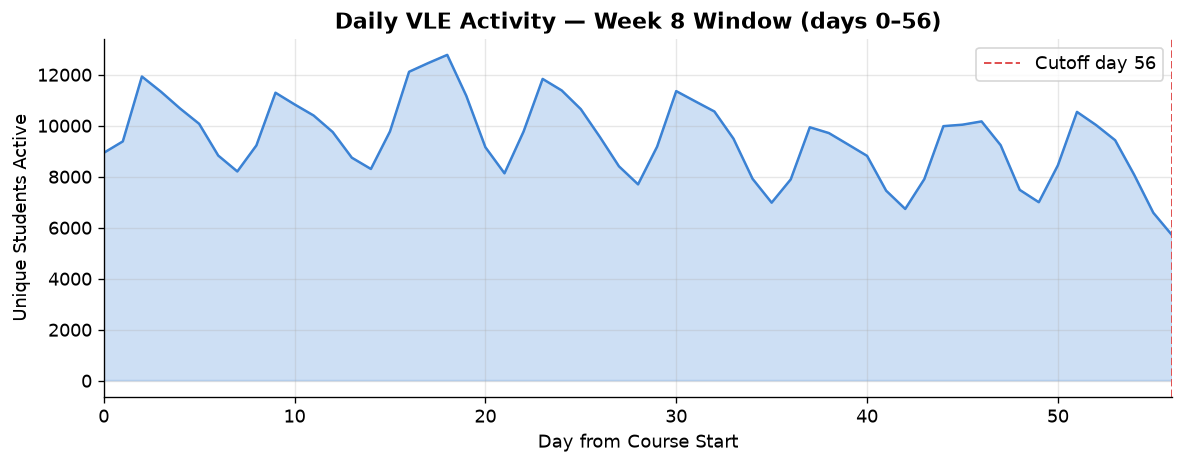

In [17]:
iw = edges['interacted_with']

# Expand first_day..last_day per edge into day-level activity
# Approximate: count students active on each day using first_day/last_day range
# More precise: use raw student_vle from result['filtered']
svle = result['filtered']['student_vle'][['id_student', 'date']].copy()
daily = svle.groupby('date')['id_student'].nunique().reset_index()
daily.columns = ['day', 'active_students']
daily = daily.sort_values('day')

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(daily['day'], daily['active_students'], alpha=0.25, color=ACCENT)
ax.plot(daily['day'], daily['active_students'], color=ACCENT, linewidth=1.5)
ax.set_xlabel('Day from Course Start')
ax.set_ylabel('Unique Students Active')
ax.set_title('Daily VLE Activity — Week 8 Window (days 0–56)', fontweight='bold')
ax.axvline(56, color=ATRISK, linewidth=1.2, linestyle='--', label='Cutoff day 56')
ax.set_xlim(0, 56)
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_vle_activity_over_time.png', bbox_inches='tight')
plt.show()


## 16. Network Visualization — Heterogeneous Graph Schema

Meta-graph of the 4 node types and 5 directed edge types.
Node size ∝ log(count); edge labels show type and total count.


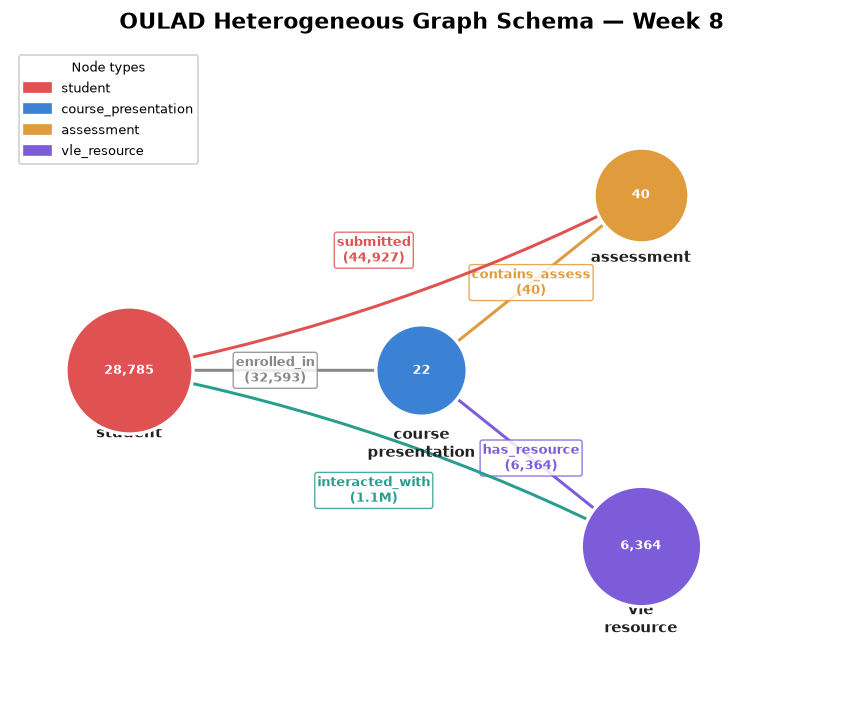

Schema diagram saved.


In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

node_meta = {
    'student':             {'count': len(nodes['student']),             'color': ATRISK},
    'course_presentation': {'count': len(nodes['course_presentation']), 'color': ACCENT},
    'assessment':          {'count': len(nodes['assessment']),          'color': '#e09b3d'},
    'vle_resource':        {'count': len(nodes['vle_resource']),        'color': '#7c5cd8'},
}
edge_meta = [
    ('student',             'course_presentation', 'enrolled_in',     len(edges['enrolled_in'])),
    ('course_presentation', 'assessment',          'contains_assess', len(edges['contains_assess'])),
    ('course_presentation', 'vle_resource',        'has_resource',    len(edges['has_resource'])),
    ('student',             'assessment',          'submitted',       len(edges['submitted'])),
    ('student',             'vle_resource',        'interacted_with', len(edges['interacted_with'])),
]
pos = {
    'student':             np.array([0.0,  0.0]),
    'course_presentation': np.array([2.0,  0.0]),
    'assessment':          np.array([3.5,  1.2]),
    'vle_resource':        np.array([3.5, -1.2]),
}
edge_colors = {
    'enrolled_in': '#888', 'contains_assess': '#e09b3d',
    'has_resource': '#7c5cd8', 'submitted': ATRISK, 'interacted_with': '#2a9d8f',
}
edge_offsets = {
    'enrolled_in': 0.0, 'contains_assess': 0.0,
    'has_resource': 0.0, 'submitted': 0.18, 'interacted_with': -0.18,
}

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_aspect('equal'); ax.axis('off')

for src, dst, etype, count in edge_meta:
    p0, p1 = pos[src], pos[dst]
    off = edge_offsets[etype]
    mid = (p0 + p1) / 2
    perp = np.array([-(p1-p0)[1], (p1-p0)[0]])
    perp = perp / np.linalg.norm(perp) * off if np.linalg.norm(perp) > 0 else perp
    ax.annotate('', xy=p1, xytext=p0,
                arrowprops=dict(arrowstyle='->', color=edge_colors[etype],
                                lw=1.8, connectionstyle=f'arc3,rad={off*0.4}'))
    lpos = mid + perp * 1.3
    short = f'{count/1e6:.1f}M' if count > 1e6 else f'{count:,}'
    ax.text(lpos[0], lpos[1], f'{etype}\n({short})',
            ha='center', va='center', fontsize=7.5,
            color=edge_colors[etype], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec=edge_colors[etype], alpha=0.85, lw=0.8))

for ntype, meta in node_meta.items():
    p = pos[ntype]
    size = 1800 + np.log10(max(meta['count'], 1)) * 900
    ax.scatter(*p, s=size, c=meta['color'], zorder=5, edgecolors='white', linewidths=2)
    ax.text(p[0], p[1], f'{meta["count"]:,}',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold', zorder=6)
    ax.text(p[0], p[1] - 0.38, ntype.replace('_', '\n'),
            ha='center', va='top', fontsize=9, color='#222', fontweight='bold')

ax.set_xlim(-0.8, 4.8); ax.set_ylim(-2.2, 2.2)
ax.set_title('OULAD Heterogeneous Graph Schema — Week 8',
             fontsize=13, fontweight='bold', pad=12)
legend_patches = [mpatches.Patch(color=m['color'], label=n)
                  for n, m in node_meta.items()]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8,
          title='Node types', title_fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_net_schema.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Schema diagram saved.')


## 17. Network Visualization — Course × VLE Activity-Type Bipartite Graph

22 course nodes (left) connected to top-10 VLE activity types (right).
Edge width ∝ resource count. Reveals course content structure.


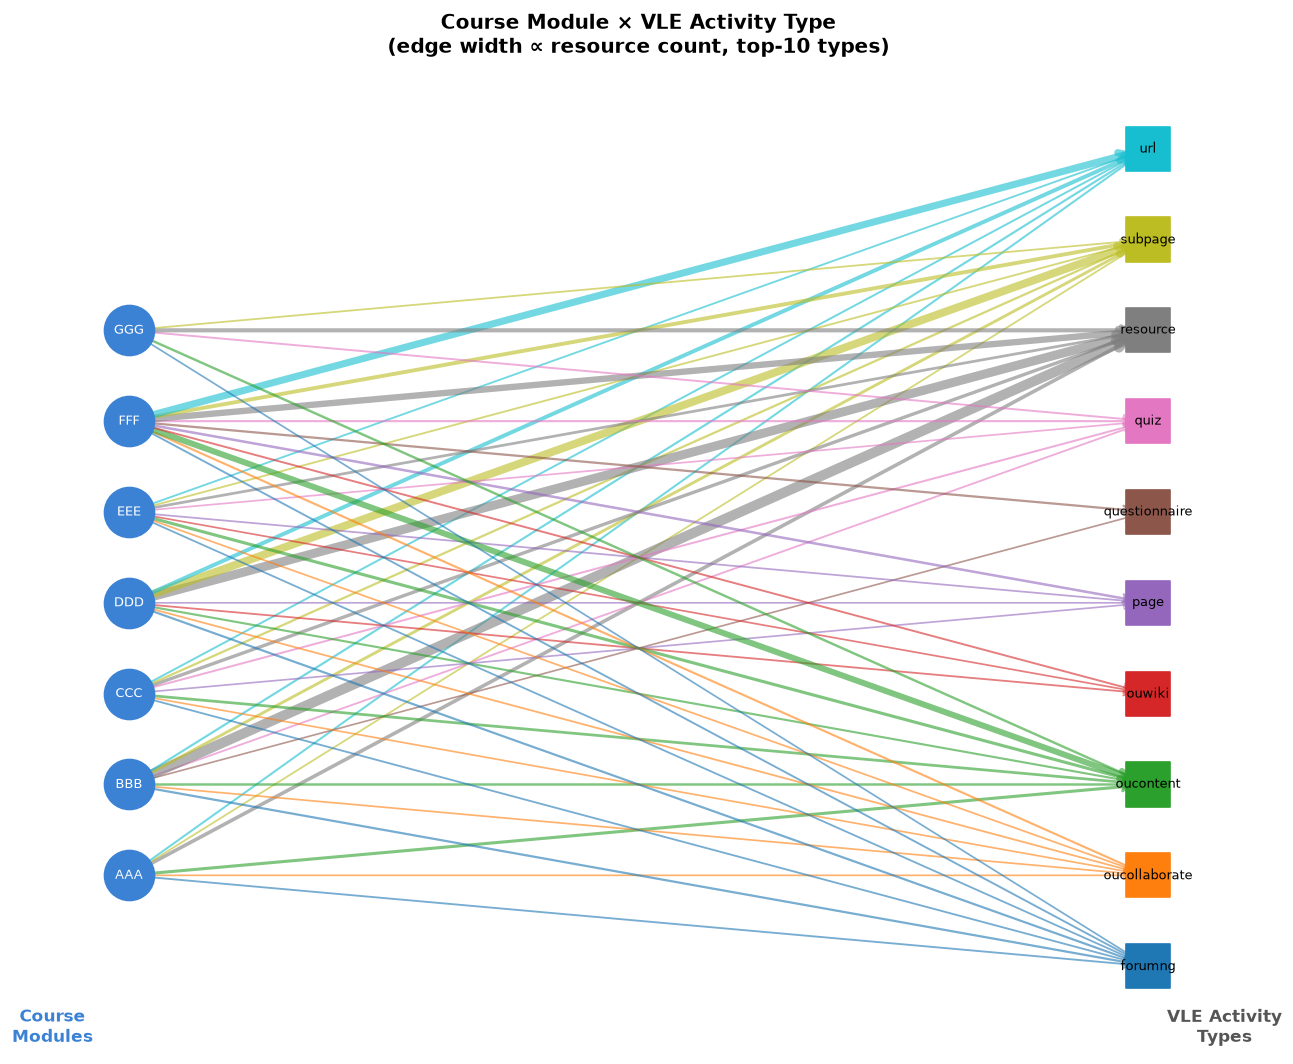

Course × VLE bipartite graph saved.


In [19]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

vle_df = nodes['vle_resource'].copy()
vle_agg = (
    vle_df.groupby(['code_module', 'activity_type'])
    .size().reset_index(name='count')
)
top_types = (
    vle_agg.groupby('activity_type')['count'].sum()
    .nlargest(10).index.tolist()
)
vle_agg = vle_agg[vle_agg['activity_type'].isin(top_types)]
modules   = sorted(vle_agg['code_module'].unique())
act_types = sorted(top_types)

G = nx.DiGraph()
for _, row in vle_agg.iterrows():
    G.add_edge(row['code_module'], row['activity_type'], weight=row['count'])

pos = {}
for i, m in enumerate(modules):
    pos[m] = np.array([-1.0, i * 1.2 - len(modules) * 0.6])
for i, a in enumerate(act_types):
    pos[a] = np.array([1.0, i * 1.2 - len(act_types) * 0.6 + 0.6])

weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w   = max(weights)
widths  = [1 + 5 * w / max_w for w in weights]

# Use plt.colormaps instead of deprecated cm.get_cmap
cmap_obj   = plt.colormaps['tab10'].resampled(len(act_types))
type_color = {a: cmap_obj(i) for i, a in enumerate(act_types)}
edge_clrs  = [type_color[v] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(11, 9))
ax.axis('off')
nx.draw_networkx_nodes(G, pos, nodelist=modules,
                       node_color=ACCENT, node_size=900, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=act_types,
                       node_color=[type_color[a] for a in act_types],
                       node_size=700, node_shape='s', ax=ax)
nx.draw_networkx_edges(G, pos, width=widths, edge_color=edge_clrs,
                       alpha=0.6, arrows=True,
                       arrowstyle='->', arrowsize=12, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white',
                        labels={m: m for m in modules}, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7.5,
                        labels={a: a for a in act_types}, ax=ax)
ax.set_title('Course Module × VLE Activity Type\n(edge width ∝ resource count, top-10 types)',
             fontsize=12, fontweight='bold')
ax.text(-1.15, min(y for x,y in pos.values()) - 1.0, 'Course\nModules',
        ha='center', fontsize=10, color=ACCENT, fontweight='bold')
ax.text( 1.15, min(y for x,y in pos.values()) - 1.0, 'VLE Activity\nTypes',
        ha='center', fontsize=10, color='#555', fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_net_course_vle.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Course × VLE bipartite graph saved.')


## 18. Network Visualization — Sampled Student–Course Enrollment Graph

300 stratified-sampled students (left) → course-presentation nodes (right).
Red = at-risk, green = success. Multi-enrollment students visible as degree > 1.


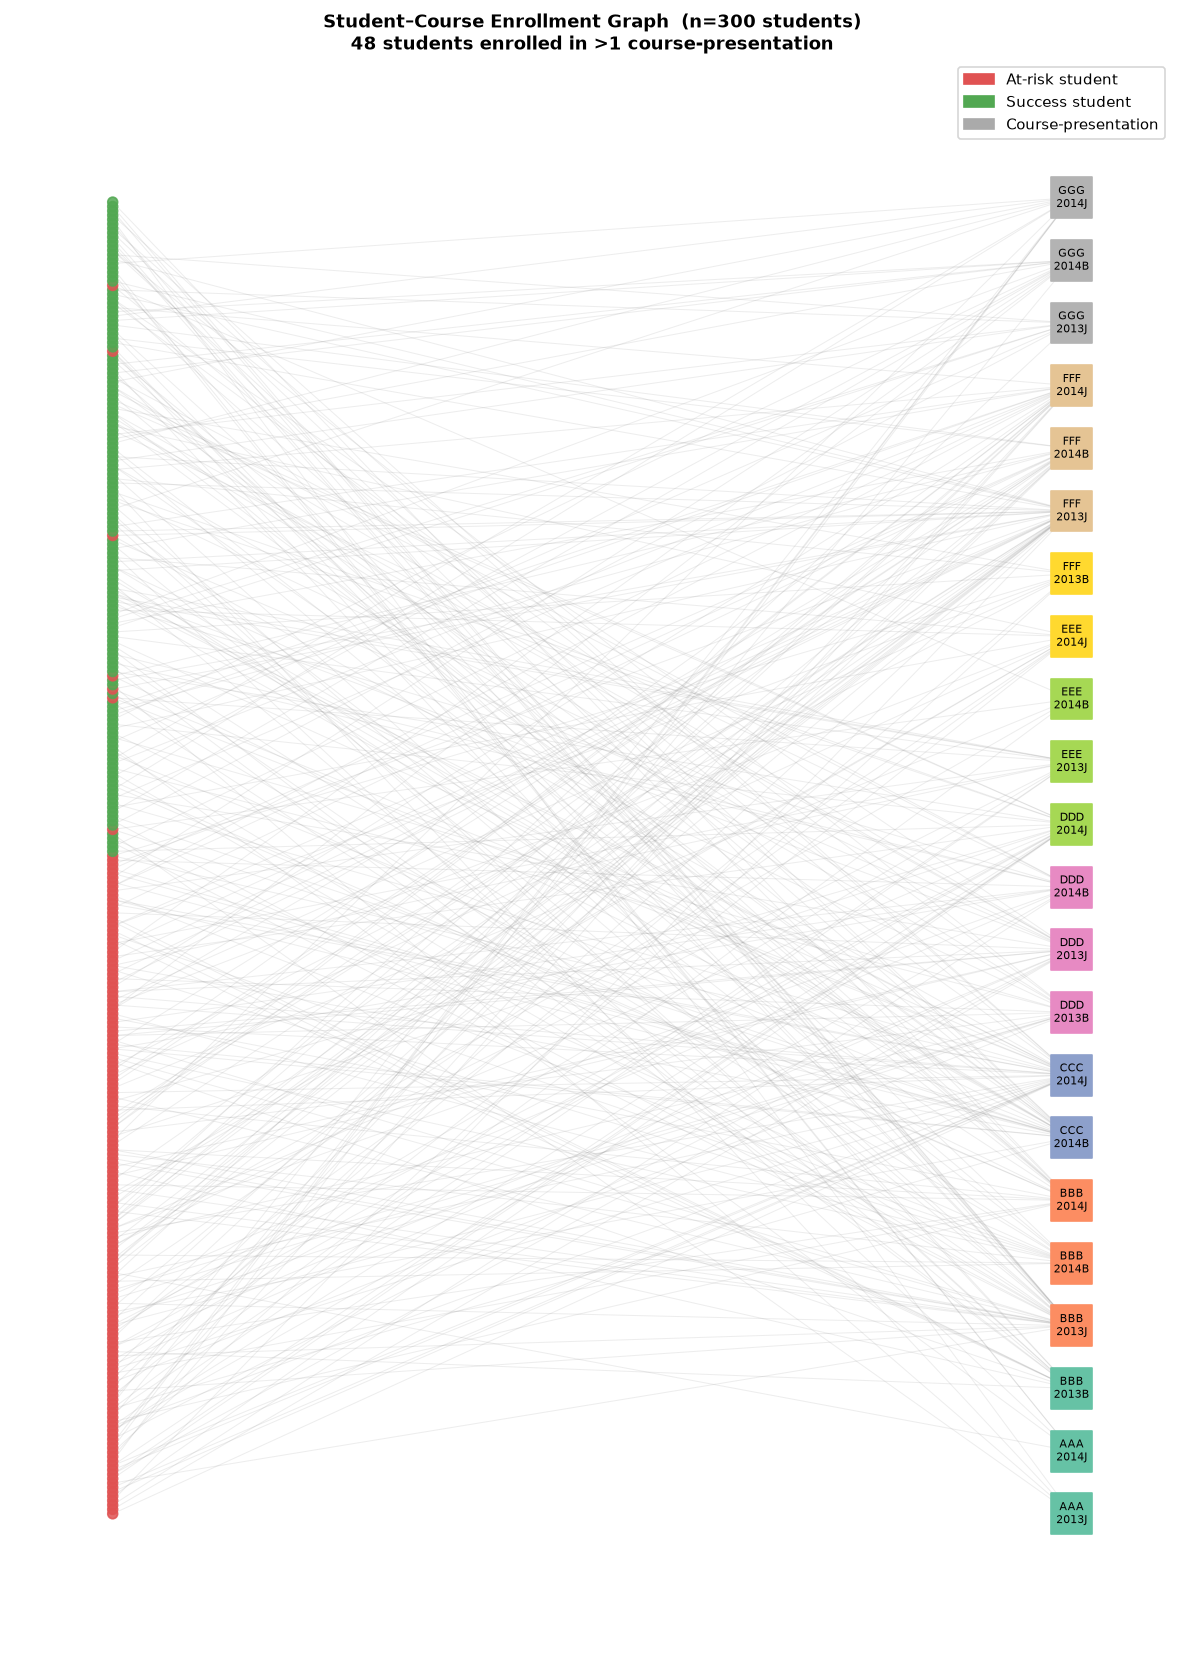

Graph: 300 students, 22 courses, 348 edges, 48 multi-enrolled students


In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

rng = np.random.default_rng(42)
at_risk_ids = enrollments[enrollments['target'] == 1]['id_student'].unique()
success_ids = enrollments[enrollments['target'] == 0]['id_student'].unique()
sampled_ids = np.concatenate([
    rng.choice(at_risk_ids,  size=min(150, len(at_risk_ids)),  replace=False),
    rng.choice(success_ids, size=min(150, len(success_ids)), replace=False),
])
sample_enroll = enrollments[enrollments['id_student'].isin(sampled_ids)].copy()
sample_enroll['cp_key'] = (
    sample_enroll['code_module'] + '_' + sample_enroll['code_presentation']
)

G = nx.Graph()
for sid in sampled_ids:
    G.add_node(f's_{sid}', ntype='student')
cp_list = sorted(sample_enroll['cp_key'].unique())
for cp in cp_list:
    G.add_node(cp, ntype='course')
for _, row in sample_enroll.iterrows():
    G.add_edge(f's_{row.id_student}', row.cp_key)

student_nodes = [n for n, d in G.nodes(data=True) if d['ntype'] == 'student']
course_nodes  = sorted([n for n, d in G.nodes(data=True) if d['ntype'] == 'course'])

pos = {}
n_stu = len(student_nodes)
for i, n in enumerate(student_nodes):
    pos[n] = np.array([0.0, float(i)])
for i, n in enumerate(course_nodes):
    pos[n] = np.array([6.0, i * (n_stu / max(len(course_nodes)-1, 1))])

student_target = (
    sample_enroll.drop_duplicates('id_student')
    .set_index('id_student')['target']
)
node_colors_s = [
    ATRISK if student_target.get(int(n.split('_')[1]), 0) == 1 else SUCCESS
    for n in student_nodes
]
cp_cmap = plt.colormaps['Set2'].resampled(len(course_nodes))
cp_color_map   = {cp: cp_cmap(i) for i, cp in enumerate(course_nodes)}
node_colors_c  = [cp_color_map[n] for n in course_nodes]

fig, ax = plt.subplots(figsize=(10, 14))
ax.axis('off')
nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color='#888', width=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=student_nodes,
                       node_color=node_colors_s, node_size=35, alpha=0.85, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=course_nodes,
                       node_color=node_colors_c, node_size=600,
                       node_shape='s', ax=ax)
nx.draw_networkx_labels(G, pos,
                        labels={n: n.replace('_', '\n') for n in course_nodes},
                        font_size=6.5, ax=ax)
multi = sample_enroll.groupby('id_student').size()
n_multi = int((multi > 1).sum())
ax.legend(
    handles=[
        mpatches.Patch(color=ATRISK,  label='At-risk student'),
        mpatches.Patch(color=SUCCESS, label='Success student'),
        mpatches.Patch(color='#aaa',  label='Course-presentation'),
    ], loc='upper right', fontsize=9
)
ax.set_title(
    f'Student–Course Enrollment Graph  (n={len(sampled_ids)} students)\n'
    f'{n_multi} students enrolled in >1 course-presentation',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_net_student_course.png',
            bbox_inches='tight', dpi=150)
plt.show()
print(f'Graph: {len(sampled_ids)} students, {len(course_nodes)} courses, '
      f'{G.number_of_edges()} edges, {n_multi} multi-enrolled students')


## 19. Network Visualization — Assessment Score vs. VLE Clicks

Each point = one student (aggregated across all enrollments).
x = total VLE clicks, y = mean assessment score, colour = at-risk label.
Motivates combining both edge types in the GNN.


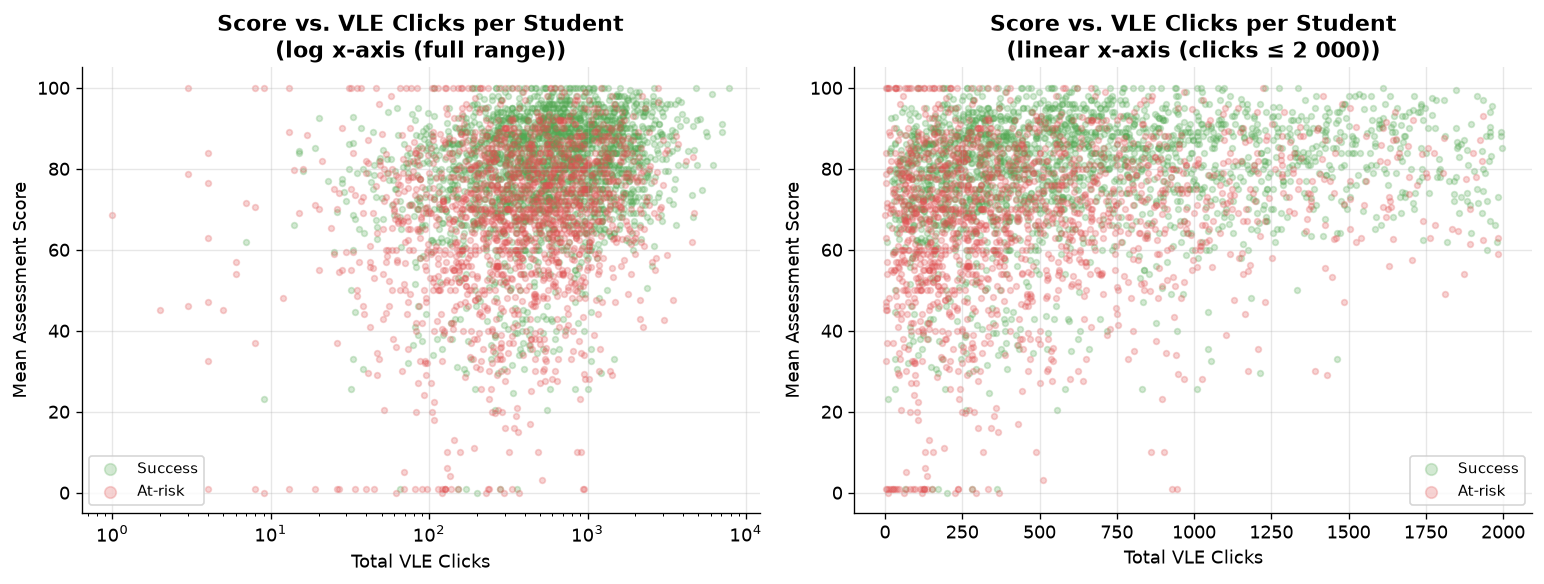

Success   median_clicks=564  median_score=82.0
At-risk   median_clicks=365  median_score=70.5


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iw_df  = edges['interacted_with'].copy()
sub_df = edges['submitted'].copy()
idx_to_student = nodes['student'].set_index('node_idx')['id_student']

clicks_per_src = iw_df.groupby('src')['total_clicks'].sum().reset_index()
clicks_per_src['id_student'] = clicks_per_src['src'].map(idx_to_student)
clicks_total = clicks_per_src.groupby('id_student')['total_clicks'].sum()

scores_per_src = sub_df.groupby('src')['score'].mean().reset_index()
scores_per_src['id_student'] = scores_per_src['src'].map(idx_to_student)
scores_mean = scores_per_src.groupby('id_student')['score'].mean()

student_label = enrollments.drop_duplicates('id_student').set_index('id_student')['target']
scatter_df = pd.DataFrame({'total_clicks': clicks_total,
                           'mean_score': scores_mean}).dropna()
scatter_df['target'] = scatter_df.index.map(student_label).astype('Int64')
scatter_df = scatter_df.dropna(subset=['target'])

rng2 = np.random.default_rng(42)
sidx = rng2.choice(len(scatter_df), size=min(4000, len(scatter_df)), replace=False)
plot_df = scatter_df.iloc[sidx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, xlog, suffix in zip(
    axes,
    [True, False],
    ['log x-axis (full range)', 'linear x-axis (clicks ≤ 2 000)']
):
    df = plot_df if xlog else plot_df[plot_df['total_clicks'] <= 2000]
    for label, color, name in [(0, SUCCESS, 'Success'), (1, ATRISK, 'At-risk')]:
        sub = df[df['target'] == label]
        ax.scatter(sub['total_clicks'], sub['mean_score'],
                   c=color, alpha=0.25, s=12, label=name, rasterized=True)
    if xlog:
        ax.set_xscale('log')
    ax.set_xlabel('Total VLE Clicks')
    ax.set_ylabel('Mean Assessment Score')
    ax.set_title(f'Score vs. VLE Clicks per Student\n({suffix})', fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results/graph/artifacts/viz_net_score_vs_clicks.png',
            bbox_inches='tight', dpi=150)
plt.show()

for label, name in [(0, 'Success'), (1, 'At-risk')]:
    sub = scatter_df[scatter_df['target'] == label]
    print(f'{name:8s}  median_clicks={sub["total_clicks"].median():.0f}  '
          f'median_score={sub["mean_score"].median():.1f}')


## 20. Unified Split Comparison

Loads the unified results table from `results/comparison/all_splits_comparison.csv`
and displays AUROC, F1, and Balanced Accuracy for all three evaluation strategies
(Random-Student, LCPO, Future-Presentation) across all 4 prediction windows.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

unified = pd.read_csv(PROJECT_ROOT / "results" / "comparison" / "all_splits_comparison.csv")

print("Unified comparison: {} rows ({} weeks x {} models x {} splits)".format(
    len(unified), unified["Week"].nunique(),
    unified["Model"].nunique(), unified["Split"].nunique()))
display(unified[[
    "Week", "Split", "Model",
    "AUROC_mean", "AUROC_std",
    "F1_mean", "F1_std",
    "Balanced_Acc_mean", "Balanced_Acc_std",
]].round(3))


Unified comparison: 52 rows (4 weeks x 5 models x 3 splits)


,Week,Split,Model,AUROC_mean,AUROC_std,F1_mean,F1_std,Balanced_Acc_mean,Balanced_Acc_std
0,2,Future-Presentation,LightGBM,0.766,0.000,0.701,0.000,0.691,0.000
1,2,Future-Presentation,LogisticRegression,0.754,0.000,0.711,0.000,0.674,0.000
2,2,Future-Presentation,RandomForest,0.745,0.000,0.686,0.000,0.676,0.000
3,2,Future-Presentation,XGBoost,0.752,0.000,0.695,0.000,0.680,0.000
4,2,LCPO,LightGBM,0.752,0.052,0.659,0.097,0.676,0.040
5,2,LCPO,LogisticRegression,0.735,0.045,0.670,0.097,0.661,0.039
6,2,LCPO,RandomForest,0.729,0.055,0.647,0.096,0.662,0.042
7,2,LCPO,XGBoost,0.742,0.050,0.654,0.100,0.669,0.042
8,2,Random-Student,LightGBM,0.769,0.005,0.704,0.003,0.698,0.004
9,2,Random-Student,LogisticRegression,0.753,0.005,0.710,0.006,0.680,0.006


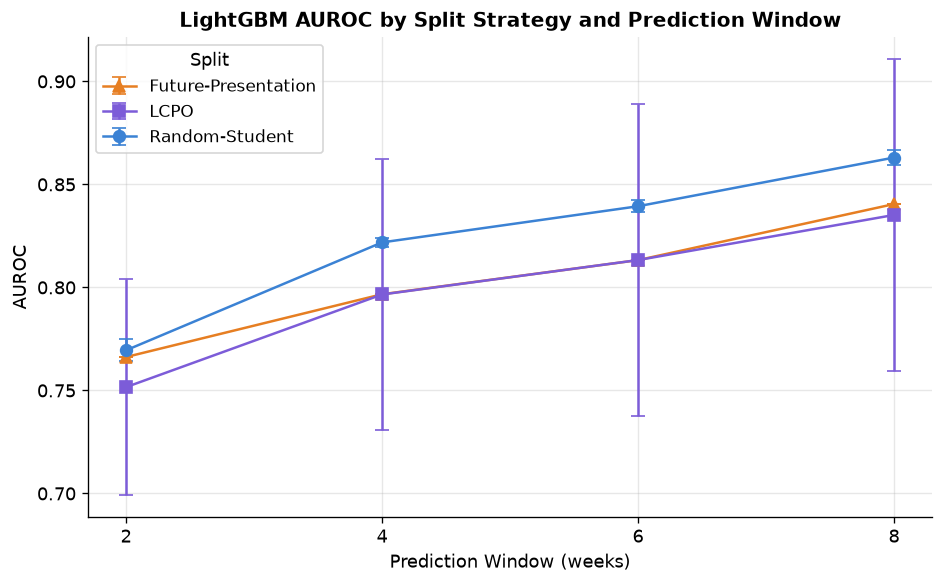

In [23]:
# AUROC by week for each split strategy (LightGBM only)
lgbm = unified[unified["Model"] == "LightGBM"].copy()

fig, ax = plt.subplots(figsize=(8, 5))
markers = {"Random-Student": "o", "LCPO": "s", "Future-Presentation": "^"}
colors  = {"Random-Student": "#3b82d4", "LCPO": "#7c5cd8", "Future-Presentation": "#e67e22"}

for split, grp in lgbm.groupby("Split"):
    grp = grp.sort_values("Week")
    ax.errorbar(
        grp["Week"], grp["AUROC_mean"], yerr=grp["AUROC_std"],
        marker=markers[split], color=colors[split], label=split,
        capsize=4, linewidth=1.5, markersize=7,
    )

ax.set_xlabel("Prediction Window (weeks)", fontsize=11)
ax.set_ylabel("AUROC", fontsize=11)
ax.set_title("LightGBM AUROC by Split Strategy and Prediction Window", fontsize=12, fontweight="bold")
ax.set_xticks([2, 4, 6, 8])
ax.legend(title="Split", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 21. Course-Level Difficulty Analysis

Shows which course-presentations are hardest (lowest AUROC) to generalize to
when using Leave-Course-Presentation-Out (LCPO) evaluation. AUROC is aggregated
across all 4 models and all 4 prediction windows (16 values per course-presentation).


In [24]:
difficulty = pd.read_csv(PROJECT_ROOT / "results" / "lcpo" / "course_presentation_difficulty.csv")

print("Course-presentation difficulty (sorted hardest to easiest):")
display(difficulty.round(3))

hardest = difficulty.iloc[0]
easiest = difficulty.iloc[-1]
print("Hardest: {} (AUROC {:.3f} +/- {:.3f})".format(
    hardest["Course_Presentation"], hardest["AUROC_mean"], hardest["AUROC_std"]))
print("Easiest: {} (AUROC {:.3f} +/- {:.3f})".format(
    easiest["Course_Presentation"], easiest["AUROC_mean"], easiest["AUROC_std"]))


Course-presentation difficulty (sorted hardest to easiest):


,Course_Presentation,AUROC_mean,AUROC_std,N_folds
0,GGG/2013J,0.627,0.017,16
1,GGG/2014B,0.641,0.018,16
2,GGG/2014J,0.665,0.014,16
3,AAA/2014J,0.707,0.043,16
4,AAA/2013J,0.728,0.039,16
5,BBB/2014J,0.762,0.036,16
6,FFF/2013B,0.795,0.034,16
7,EEE/2014B,0.809,0.040,16
8,FFF/2014B,0.810,0.034,16
9,EEE/2013J,0.816,0.041,16


Hardest: GGG/2013J (AUROC 0.627 +/- 0.017)
Easiest: CCC/2014B (AUROC 0.850 +/- 0.046)


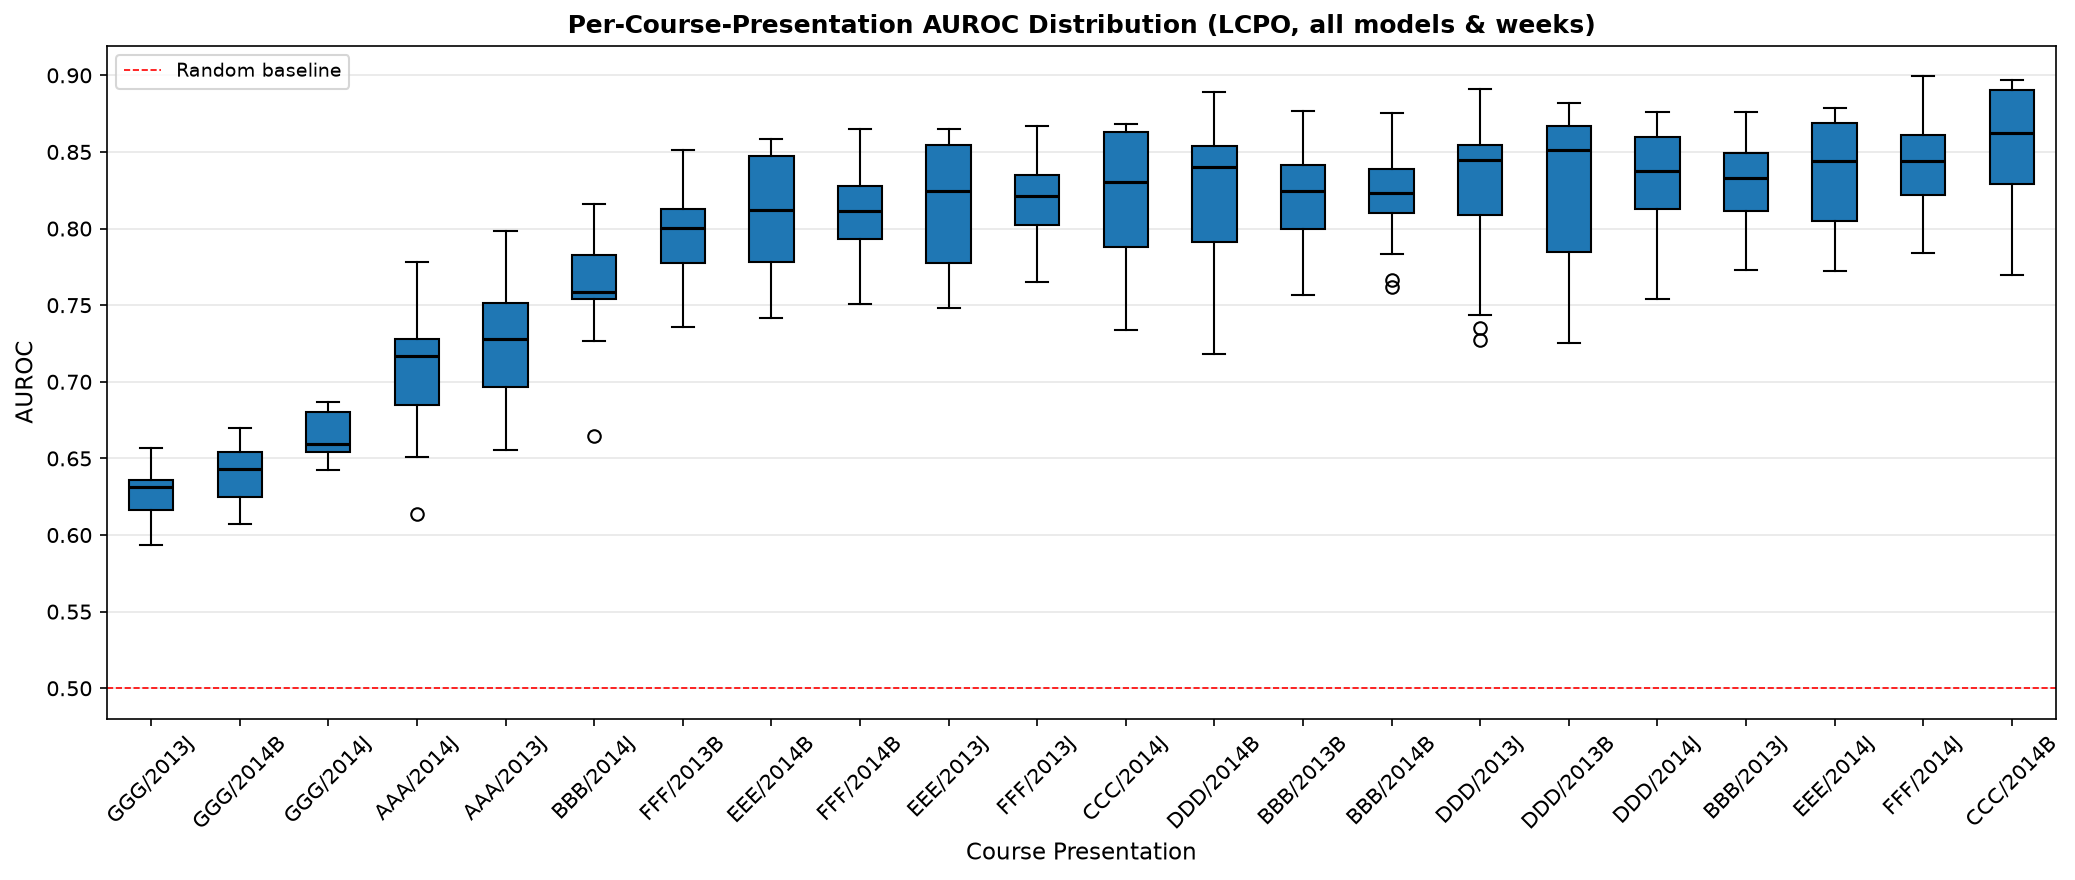

In [25]:
from IPython.display import Image

chart_path = PROJECT_ROOT / "results" / "lcpo" / "course_difficulty_chart.png"
if chart_path.exists():
    display(Image(str(chart_path), width=900))
else:
    print(f"Chart not found at {chart_path}. Run src/run_evaluation.py first.")


---

*Notebook complete. GNN training (GraphSAGE, random-student and LCPO evaluation) follows in the next iteration.*
